# Clasificación de arquitectura y plataforma

El notebook limpia un volcado, extrae slugs, crea categorías mediante reglas, genera características TF-IDF de caracteres y entrena un clasificador balanceado. La evaluación se realiza sobre una partición estratificada 70/30.

Para preparar un entorno Jupyter local, instala las dependencias con `pip install pandas scikit-learn scipy matplotlib seaborn`. En Google Colab, cambia `CARGAR_ARCHIVO_EN_COLAB` a `True` en la celda de código y sube el archivo. Los archivos de texto plano se interpretan como un registro por línea; es preferible que cada registro incluya un campo como `slug=...` o `project_name=...`.

Las categorías son etiquetas heurísticas creadas por reglas técnicas. La evaluación mide qué tan bien el modelo reproduce esas reglas, no verifica por sí sola la plataforma real de cada juego.

Archivo de entrada: game_info_cleaned.csv
Registros extraídos: 474,401

Distribución de categorías objetivo (etiquetas creadas por reglas):


,registros
categoria,
Desktop Standalone,257583
Web/HTML5,111748
Prototipo / Assets,104803
Multiplataforma,267


,slug_limpio,categoria_plataforma,longitud_slug,cantidad_palabras,tiene_guion
0,dgeneration-hd,Desktop Standalone,14,2,1
1,g-prime,Desktop Standalone,7,2,1
2,land-sliders,Prototipo / Assets,12,2,1
3,pixel-gear,Desktop Standalone,10,2,1
4,gods-and-idols,Desktop Standalone,14,3,1
5,plague-venue,Web/HTML5,12,2,1
6,the-moon-sliver-itch,Desktop Standalone,20,4,1
7,red-entity,Desktop Standalone,10,2,1
8,hippiesvscops,Desktop Standalone,13,1,0
9,they-came-through-the-floor,Desktop Standalone,27,5,1


Accuracy: 0.5733
Precision macro: 0.5802
Recall macro: 0.6050
F1 macro: 0.5914

Informe de clasificación:
                    precision    recall  f1-score   support

         Web/HTML5       0.37      0.32      0.35     33525
Desktop Standalone       0.65      0.66      0.66     77275
   Multiplataforma       0.73      0.81      0.77        80
Prototipo / Assets       0.57      0.62      0.59     31441

          accuracy                           0.57    142321
         macro avg       0.58      0.60      0.59    142321
      weighted avg       0.57      0.57      0.57    142321



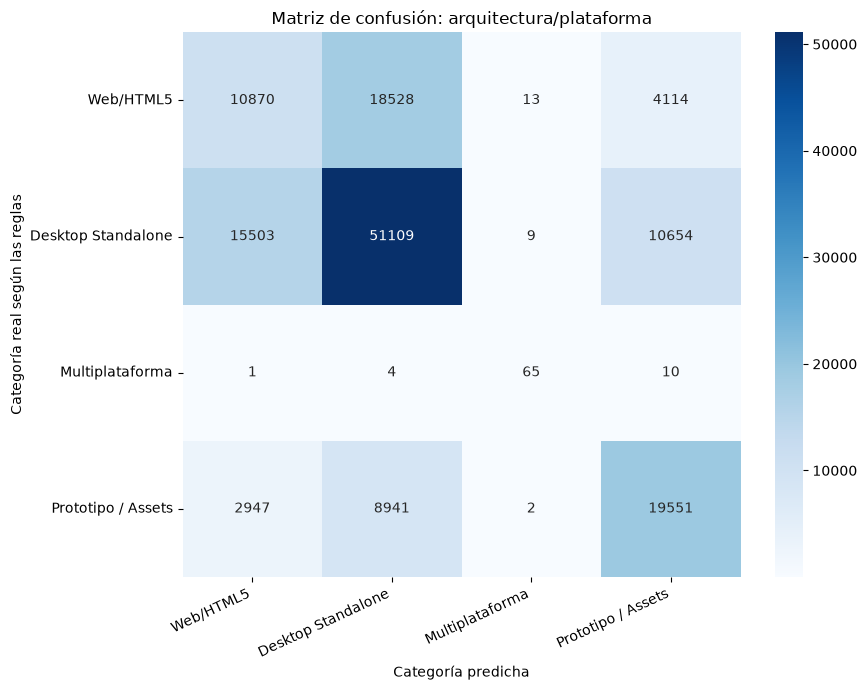


CONCLUSIÓN EN LENGUAJE SENCILLO
El modelo leyó los nombres de los proyectos buscando combinaciones de letras frecuentes y tres características sencillas del slug. La división estratificada mantuvo la proporción de categorías entre entrenamiento y prueba, y los pesos balanceados dieron más importancia a las categorías menos frecuentes. En datos no vistos obtuvo accuracy de 57.3% y F1 macro de 59.1%. En esta prueba el rendimiento aún no es suficientemente alto para confiar en la clasificación automática. Estas métricas miden qué tan bien reproduce las categorías asignadas por las reglas; no prueban por sí solas la arquitectura real del juego. Para afirmar una precisión alta en proyectos reales, las etiquetas deben verificarse con información oficial y el resultado debe confirmarse en una muestra independiente.


In [ ]:
# ============================================================
# CLASIFICADOR DE ARQUITECTURA / PLATAFORMA DE VIDEOJUEGOS
# Ejecutable en Jupyter y Google Colab
# ============================================================

import importlib
import io
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


# ETAPA 0: seleccionar el archivo.
# En Colab, cambia CARGAR_ARCHIVO_EN_COLAB a True para abrir el selector de archivos.
CARGAR_ARCHIVO_EN_COLAB = False
RUTA_ENTRADA = None  # Ejemplo local: Path('../data/volcado_juegos.txt')

if CARGAR_ARCHIVO_EN_COLAB:
    try:
        files = importlib.import_module('google.colab.files')
    except ImportError as error:
        raise RuntimeError('La carga interactiva solo está disponible en Google Colab.') from error
    archivos_subidos = files.upload()
    if not archivos_subidos:
        raise ValueError('No se seleccionó ningún archivo.')
    nombre_archivo, contenido_archivo = next(iter(archivos_subidos.items()))
else:
    if RUTA_ENTRADA is not None:
        ruta_entrada = Path(RUTA_ENTRADA)
    else:
        candidatos = [
            Path('../data/game_info_cleaned.csv'),
            Path('data/game_info_cleaned.csv'),
            Path('../dataset_juegos.csv'),
            Path('dataset_juegos.csv'),
        ]
        ruta_entrada = next((ruta for ruta in candidatos if ruta.exists()), None)
    if ruta_entrada is None or not ruta_entrada.exists():
        raise FileNotFoundError(
            'No se encontró el archivo. Define RUTA_ENTRADA o activa '
            'CARGAR_ARCHIVO_EN_COLAB. Para TXT/LOG, usa un registro por línea.'
        )
    nombre_archivo = ruta_entrada.name
    contenido_archivo = ruta_entrada.read_bytes()

print(f'Archivo de entrada: {nombre_archivo}')


# ETAPA 1: limpieza de ruido y parsing de registros.
def limpiar_texto(valor):
    if valor is None or pd.isna(valor):
        return ''
    texto = str(valor).replace('||', ' ')
    texto = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', ' ', texto)
    texto = re.sub(r'[\u2500-\u259F]', ' ', texto)
    texto = re.sub(r'\b0x[0-9a-f]{6,}\b', ' ', texto, flags=re.IGNORECASE)
    texto = re.sub(r'\b[A-Za-z0-9+/]{40,}={0,2}\b', ' ', texto)
    texto = re.sub(r'([^\w\s])\1{4,}', ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


def limpiar_slug(valor):
    texto = unicodedata.normalize('NFKD', str(valor or '').strip())
    texto = texto.encode('ascii', 'ignore').decode('ascii').lower()
    texto = re.sub(r'[^a-z0-9]+', '-', texto)
    return texto.strip('-')


PATRON_CAMPO_NOMBRE = re.compile(
    r'(?:slug|game_slug|project_slug|project_name|game_name|name)\s*[:=]\s*["\']?([^,;|}\]]{2,120})',
    flags=re.IGNORECASE,
)
TOKENS_NO_SLUG = {
    'slug', 'name', 'project', 'game', 'platform', 'platforms', 'build', 'tag',
    'tags', 'event', 'events', 'win', 'win32', 'win64', 'windows', 'osxa', 'osx',
    'mac', 'html5', 'web', 'webgl', 'browser', 'pc', 'exe', 'linux', 'cross',
    'demo', 'vr', 'unity', 'unreal', 'godot', 'id', 'null', 'none',
}


def extraer_slug_de_linea(linea):
    coincidencia = PATRON_CAMPO_NOMBRE.search(linea)
    if coincidencia:
        valor = coincidencia.group(1).strip().strip('"\' ')
        slug = limpiar_slug(valor)
        if slug:
            return slug

    tokens = re.findall(r'(?<![A-Za-z0-9])([A-Za-z0-9][A-Za-z0-9._-]{2,79})(?![A-Za-z0-9])', linea)
    tokens = [token for token in tokens if token.lower().strip('._-') not in TOKENS_NO_SLUG]
    token_con_guion = next((token for token in tokens if '-' in token), None)
    candidato = token_con_guion or (tokens[0] if tokens else '')
    return limpiar_slug(candidato)


def registros_desde_csv(datos_csv):
    origen = pd.read_csv(io.BytesIO(datos_csv), low_memory=False)
    columnas_por_nombre = {columna.lower(): columna for columna in origen.columns}
    columna_slug = next(
        (columnas_por_nombre[nombre] for nombre in ('slug', 'slug_juego', 'project_slug', 'game_slug') if nombre in columnas_por_nombre),
        None,
    )
    columna_nombre = next(
        (columnas_por_nombre[nombre] for nombre in ('name', 'nombre', 'game_name', 'project_name') if nombre in columnas_por_nombre),
        None,
    )
    columnas_texto = [
        columna for columna in origen.columns
        if columna.lower() in {'slug', 'slug_juego', 'name', 'nombre', 'platform', 'platforms', 'genres', 'tags', 'tag', 'build', 'builds', 'event', 'events', 'description', 'summary'}
        or any(pista in columna.lower() for pista in ('platform', 'tag', 'build', 'event', 'description', 'technical'))
    ]
    if not columnas_texto:
        columnas_texto = list(origen.select_dtypes(include=['object', 'string']).columns)
    if not columnas_texto:
        raise ValueError('El CSV no contiene columnas de texto utilizables.')

    valores_limpios = [
        [limpiar_texto(valor) for valor in origen[columna].fillna('').to_numpy()]
        for columna in columnas_texto
    ]
    textos = [' '.join(valor for valor in fila if valor) for fila in zip(*valores_limpios)]
    if columna_slug:
        slugs_origen = [limpiar_texto(valor) for valor in origen[columna_slug].fillna('').to_numpy()]
    else:
        slugs_origen = [''] * len(origen)
    if columna_nombre:
        nombres = [limpiar_texto(valor) for valor in origen[columna_nombre].fillna('').to_numpy()]
    else:
        nombres = [''] * len(origen)

    filas = []
    for slug_origen, nombre, texto in zip(slugs_origen, nombres, textos):
        slug = limpiar_slug(slug_origen or nombre or extraer_slug_de_linea(texto))
        if slug and texto:
            filas.append({'slug_limpio': slug, 'texto_registro': texto})
    return pd.DataFrame(filas)


def registros_desde_texto(contenido):
    texto = contenido.decode('utf-8', errors='replace')
    filas = []
    for linea in texto.splitlines():
        linea_limpia = limpiar_texto(linea)
        if not linea_limpia:
            continue
        slug = extraer_slug_de_linea(linea_limpia)
        if slug:
            filas.append({'slug_limpio': slug, 'texto_registro': linea_limpia})
    return pd.DataFrame(filas)


if nombre_archivo.lower().endswith('.csv'):
    juegos = registros_desde_csv(contenido_archivo)
else:
    juegos = registros_desde_texto(contenido_archivo)

if juegos.empty:
    raise ValueError(
        'No se extrajeron registros. En archivos TXT/LOG se espera un proyecto por línea, '
        'preferiblemente con un campo slug=..., name=... o project_name=... .'
    )
juegos = juegos.drop_duplicates(subset=['slug_limpio', 'texto_registro']).reset_index(drop=True)


# ETAPA 1b: etiqueta objetivo por reglas explícitas, en orden de prioridad.
PATRON_WEB = re.compile(r'(?<![a-z0-9])(?:html5|webgl|browser|web)(?![a-z0-9])', re.IGNORECASE)
PATRON_MULTIPLATAFORMA = re.compile(
    r'(?<![a-z0-9])(?:win64[\s_-]*osxa|mac[\s_-]*win|cross|osxa)(?![a-z0-9])',
    re.IGNORECASE,
)
PATRON_DESKTOP = re.compile(
    r'(?<![a-z0-9])(?:win(?:32|64)?|windows|exe|pc|linux)(?![a-z0-9])',
    re.IGNORECASE,
)


def asignar_categoria(texto):
    if PATRON_WEB.search(texto):
        return 'Web/HTML5'
    if PATRON_MULTIPLATAFORMA.search(texto):
        return 'Multiplataforma'
    if PATRON_DESKTOP.search(texto):
        return 'Desktop Standalone'
    return 'Prototipo / Assets'


juegos['categoria_plataforma'] = juegos['texto_registro'].map(asignar_categoria)
juegos['longitud_slug'] = juegos['slug_limpio'].str.len()
juegos['cantidad_palabras'] = juegos['slug_limpio'].str.findall(r'[a-z0-9]+').str.len()
juegos['tiene_guion'] = juegos['slug_limpio'].str.contains('-', regex=False).astype(int)
juegos.to_csv('dataset_plataformas_clasificacion.csv', index=False, encoding='utf-8-sig')

print(f'Registros extraídos: {len(juegos):,}')
print('\nDistribución de categorías objetivo (etiquetas creadas por reglas):')
display(juegos['categoria_plataforma'].value_counts().rename_axis('categoria').to_frame('registros'))
display(juegos[['slug_limpio', 'categoria_plataforma', 'longitud_slug', 'cantidad_palabras', 'tiene_guion']].head(10))


# ETAPA 2 y 3: TF-IDF de caracteres + métricas; split estratificado 70/30;
# LinearSVC con ponderación balanceada para reducir el sesgo hacia la clase mayoritaria.
CLASES = ['Web/HTML5', 'Desktop Standalone', 'Multiplataforma', 'Prototipo / Assets']
conteos = juegos['categoria_plataforma'].value_counts()
if juegos['categoria_plataforma'].nunique() < 2:
    raise ValueError('Solo se encontró una categoría. Se necesita texto con señales de al menos dos clases para entrenar.')
if conteos.min() < 2:
    escasas = conteos[conteos < 2].to_dict()
    raise ValueError(f'Hay clases con menos de 2 ejemplos ({escasas}); se necesitan más registros para dividir train/test de forma estratificada.')

columnas_numericas = ['longitud_slug', 'cantidad_palabras', 'tiene_guion']
X = juegos[['slug_limpio'] + columnas_numericas]
y = juegos['categoria_plataforma']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

transformador = ColumnTransformer(
    transformers=[
        ('tfidf_caracteres', TfidfVectorizer(
            analyzer='char',
            ngram_range=(2, 5),
            min_df=1,
            max_features=30000,
            sublinear_tf=True,
        ), 'slug_limpio'),
        ('metricas_slug', StandardScaler(), columnas_numericas),
    ],
    remainder='drop',
)
modelo = Pipeline(steps=[
    ('caracteristicas', transformador),
    ('clasificador', LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)),
])
modelo.fit(X_train, y_train)
predicciones = modelo.predict(X_test)


# ETAPA 4: evaluación y matriz de confusión.
accuracy = accuracy_score(y_test, predicciones)
precision_macro = precision_score(y_test, predicciones, average='macro', zero_division=0)
recall_macro = recall_score(y_test, predicciones, average='macro', zero_division=0)
f1_macro = f1_score(y_test, predicciones, average='macro', zero_division=0)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision macro: {precision_macro:.4f}')
print(f'Recall macro: {recall_macro:.4f}')
print(f'F1 macro: {f1_macro:.4f}')
print('\nInforme de clasificación:')
print(classification_report(y_test, predicciones, labels=CLASES, target_names=CLASES, zero_division=0))

clases_presentes = [clase for clase in CLASES if clase in juegos['categoria_plataforma'].unique()]
matriz = confusion_matrix(y_test, predicciones, labels=clases_presentes)
plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clases_presentes,
    yticklabels=clases_presentes,
)
plt.title('Matriz de confusión: arquitectura/plataforma')
plt.xlabel('Categoría predicha')
plt.ylabel('Categoría real según las reglas')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ETAPA 5: conclusión en lenguaje sencillo basada en la evaluación obtenida.
if f1_macro >= 0.80:
    lectura_rendimiento = 'En esta prueba el rendimiento por categoría es alto.'
elif f1_macro >= 0.60:
    lectura_rendimiento = 'En esta prueba el rendimiento es razonable, pero hay categorías que todavía se confunden.'
else:
    lectura_rendimiento = 'En esta prueba el rendimiento aún no es suficientemente alto para confiar en la clasificación automática.'

conclusion = (
    f'El modelo leyó los nombres de los proyectos buscando combinaciones de letras frecuentes y '
    f'tres características sencillas del slug. La división estratificada mantuvo la proporción de '
    f'categorías entre entrenamiento y prueba, y los pesos balanceados dieron más importancia a '
    f'las categorías menos frecuentes. En datos no vistos obtuvo accuracy de {accuracy:.1%} y F1 '
    f'macro de {f1_macro:.1%}. {lectura_rendimiento} Estas métricas miden qué tan bien reproduce '
    f'las categorías asignadas por las reglas; no prueban por sí solas la arquitectura real del juego. '
    f'Para afirmar una precisión alta en proyectos reales, las etiquetas deben verificarse con '
    f'información oficial y el resultado debe confirmarse en una muestra independiente.'
)
print('\nCONCLUSIÓN EN LENGUAJE SENCILLO')
print(conclusion)